---
title: GitHub Repository Analysis
format: html
---

## Libraries & Imports

In [1]:
pip install requests

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
from requests.auth import HTTPBasicAuth
from urllib.parse import quote
import pandas as pd
import matplotlib.pyplot as plt

## OrientDB

### OrientDB Configuration

In [3]:
ORIENTDB_HOST = 'http://orientdb:2480'
ORIENTDB_USER = 'ROOT'
ORIENTDB_PASSWORD = 'fhdw'
ORIENTDB_DATABASE = 'github'

### OrientDB REST API Wrapper

In [4]:
class OrientDB:

    def __init__(self, host: str, user: str, password: str, database: str):
        self.host = host
        self.authentication = HTTPBasicAuth(user, password)
        self.session = requests.Session()
        self.database = database
    
    def get(self, endpoint: str):
        return self.session.get(f"{self.host}{endpoint}", auth=self.authentication)
    
    def post(self, endpoint, body = None):
        return self.session.post(f"{self.host}{endpoint}", auth=self.authentication, json=body)

    def query(self, query):
        response = self.get(f'/query/{self.database}/sql/{quote(query, safe="")}/{1000000}')
    
        if response.status_code == 400:
            print(f"Failed to execute {query} on {self.database}.")
            return

        return response.json()

    def command(self, command):
        return self.post(f"/command/{self.database}/sql", command)
    
    def function_exists(self, name):
        response = self.query(f"SELECT FROM OFunction WHERE name = '{name}'")
        return len(response['result']) != 0

database = OrientDB(ORIENTDB_HOST, ORIENTDB_USER, ORIENTDB_PASSWORD, ORIENTDB_DATABASE)

## OrientDB Function for Average Weekly Merged PRS

In [5]:
if not database.function_exists('averageWeeklyMergedPRs'):
    function_body = (
        "SELECT "
        "  total / ($timespan / $week_ms + 1) AS average_weekly_merged_prs "
        "FROM $stats "
        "LET "
        "  $stats = ("
        "    SELECT "
        "      count(*) AS total, "
        "      min(date(merged_at, 'yyyy-MM-dd\\'T\\'HH:mm:ss\\'Z\\'')) AS first_merged_pr, "
        "      max(date(merged_at, 'yyyy-MM-dd\\'T\\'HH:mm:ss\\'Z\\'')) AS last_merged_pr "
        "    FROM pull_requests "
        "    WHERE repo_id = :repo_id "
        "    PARALLEL"
        "  ), "
        "  $timespan = last_merged_pr.asLong() - first_merged_pr.asLong(), "
        "  $week_ms = 1000 * 60 * 60 * 24 * 7 "
        "WHERE total > 1"
    )

    response = database.command({
        "command": f"""
        CREATE FUNCTION averageWeeklyMergedPRs "{function_body}"
        PARAMETERS [repo_id]
        IDEMPOTENT true
        LANGUAGE SQL
        """
    })

    print(response.json())
else:
    print('Function already exists, skipping creation')

{'result': [{'operation': 'create function', 'functionName': 'averageWeeklyMergedPRs', 'finalId': '#7:0'}], 'dbStats': {'@type': 'd', '@version': 0, '@fieldTypes': 'loadedRecords=l,averageLoadRecordTimeMs=l,minLoadRecordTimeMs=l,maxLoadRecordTimeMs=l,prefetchedRidbagsCount=l,ridbagPrefetchTimeMs=l,minRidbagPrefetchTimeMs=l,maxRidbagPrefetchTimeMs=l', 'loadedRecords': 0, 'averageLoadRecordTimeMs': 0, 'minLoadRecordTimeMs': 0, 'maxLoadRecordTimeMs': 0, 'prefetchedRidbagsCount': 0, 'ridbagPrefetchTimeMs': 0, 'minRidbagPrefetchTimeMs': 0, 'maxRidbagPrefetchTimeMs': 0}, 'elapsedMs': 3}


## Analysis

### Repositories

#### Query

In [6]:
def repositories():
    query = f"""
    SELECT
        full_name,
        description,
        stars,
        language
    FROM repositories
    ORDER BY stars desc
    """

    return database.query(query)['result']

repositories_result = repositories()

#### Visualization

In [7]:
pd.DataFrame(repositories_result)

,full_name,description,stars,language
0,codecrafters-io/build-your-own-x,Master programming by recreating your favorite...,513096,Markdown
1,sindresorhus/awesome,😎 Awesome lists about all kinds of interesting...,473977,None
2,freeCodeCamp/freeCodeCamp,freeCodeCamp.org's open-source codebase and cu...,446434,TypeScript
3,public-apis/public-apis,A collective list of free APIs,440235,Python
4,EbookFoundation/free-programming-books,:books: Freely available programming books,389883,Python
...,...,...,...,...
195,OpenHands/OpenHands,🙌 OpenHands: AI-Driven Development,76255,Python
196,sdmg15/Best-websites-a-programmer-should-visit,:link: Some useful websites for programmers.,76126,None
197,awesomedata/awesome-public-datasets,A topic-centric list of HQ open datasets.,75888,None
198,nestjs/nest,A progressive Node.js framework for building e...,75743,TypeScript


### Pull Requests Timeline

#### Query

In [8]:
def pull_request_timeline():
    query = f"""
    SELECT
        repo_id,
        date(merged_at, "yyyy-MM-dd'T'HH:mm:ss'Z'").format('yyyy-ww') AS week,
        COUNT(*) AS merged_prs
    FROM pull_requests
    GROUP BY repo_id, week
    """

    return database.query(query)['result']

pull_request_timeline_result = pull_request_timeline()

#### Visualization

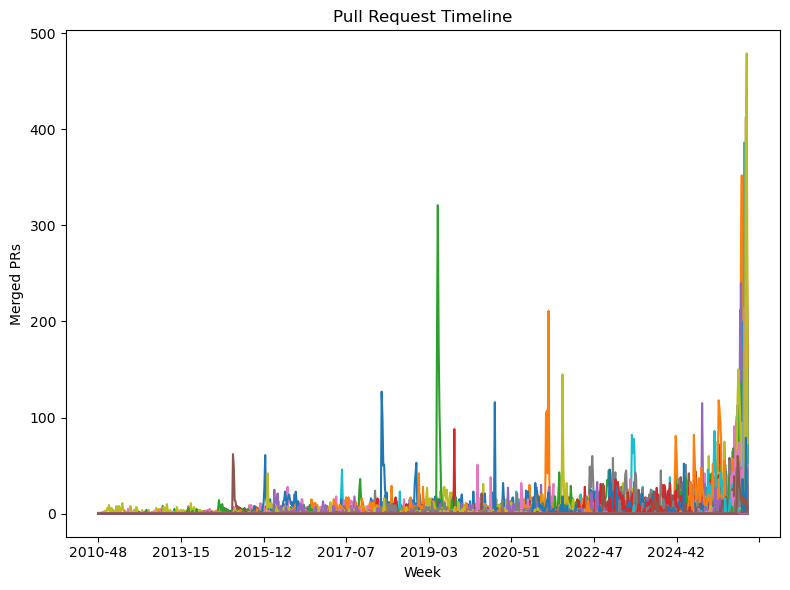

In [9]:
def visualize_pull_request_timeline():
    df = pd.DataFrame(pull_request_timeline_result)
    df = df[['repo_id', 'week', 'merged_prs']]

    df = df.sort_values(['week', 'repo_id'])

    pivot = df.pivot(index='week', columns='repo_id', values='merged_prs')
    pivot = pivot.fillna(0)

    axes = pivot.plot(figsize=(8, 6), legend=False)

    axes.set_xlabel('Week')
    axes.set_ylabel('Merged PRs')
    axes.set_title('Pull Request Timeline')

    plt.tight_layout()
    plt.show()

visualize_pull_request_timeline()

### Repository stars vs average weekly merged PRs
#### Query

In [10]:
def average_prs_per_week():
    average_prs_per_week_query = """
    SELECT
        id,
        full_name,
        stars,
        ifnull(averageWeeklyMergedPRs(id)[0].average_weekly_merged_prs, 0) AS average_prs_per_week
    FROM repositories
    PARALLEL
    """

    return database.query(average_prs_per_week_query)['result']

average_prs_per_week_result = average_prs_per_week()

#### Visualization

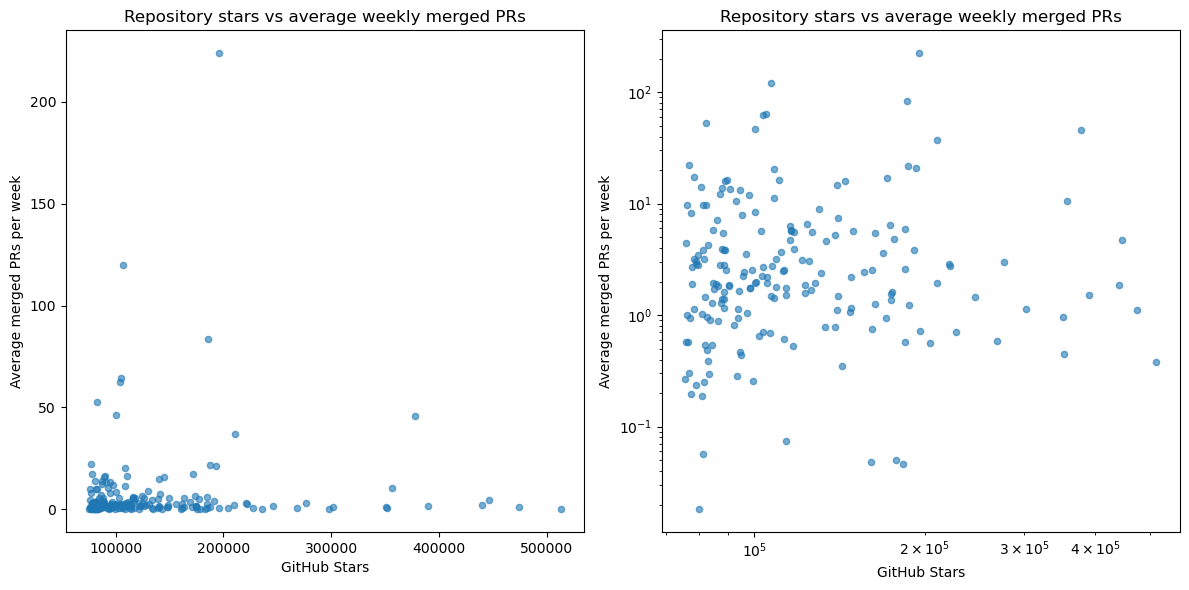

In [11]:
def visualize_average_prs_per_week():
    df = pd.DataFrame(average_prs_per_week_result)
    figure, axes = plt.subplots(1, 2, figsize=(12, 6))

    axes_linear = axes[0]
    axes_linear.scatter(df['stars'], df['average_prs_per_week'], s=20, alpha=0.6)
    axes_linear.set_xlabel('GitHub Stars')
    axes_linear.set_ylabel('Average merged PRs per week')
    axes_linear.set_title('Repository stars vs average weekly merged PRs')

    axes_log = axes[1]
    axes_log.scatter(df['stars'], df['average_prs_per_week'], s=20, alpha=0.6)
    axes_log.set_xlabel('GitHub Stars')
    axes_log.set_ylabel('Average merged PRs per week')
    axes_log.set_title('Repository stars vs average weekly merged PRs')

    axes_log.set_xscale('log')
    axes_log.set_yscale('log')

    plt.tight_layout()
    plt.show()

visualize_average_prs_per_week()

### Average Weekly Merged PRs per Language
#### Query

In [12]:
def average_merged_prs_per_week_per_language():
    average_merged_prs_per_week_per_language_query = """
    SELECT
		language,
        avg($average_weekly_merged_prs) AS average_prs_per_week
    FROM repositories
    LET
        $average_weekly_merged_prs = ifnull(averageWeeklyMergedPRs(id)[0].average_weekly_merged_prs, 0)
    GROUP BY language
    PARALLEL
    """

    return database.query(average_merged_prs_per_week_per_language_query)['result']

average_merged_prs_per_week_per_language_result = average_merged_prs_per_week_per_language()

#### Visualization

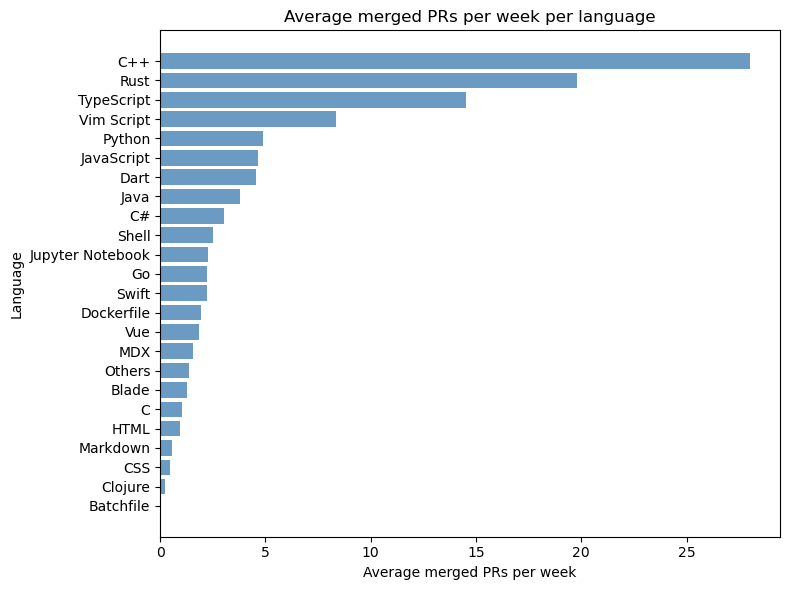

In [13]:
def visualize_per_language_activity():
    df = pd.DataFrame(average_merged_prs_per_week_per_language_result)
    df['language'] = df['language'].fillna('Others')
    df = df.sort_values('average_prs_per_week', ascending=True)

    figure, axes = plt.subplots(figsize=(8, 6))

    axes.barh(df['language'], df['average_prs_per_week'], color='steelblue', alpha=0.8)
    axes.set_xlabel('Average merged PRs per week')
    axes.set_ylabel('Language')
    axes.set_title('Average merged PRs per week per language')

    plt.tight_layout()
    plt.show()

visualize_per_language_activity()